# Hybrid Scheme for fractional Brownian motion and rough volatility simulation

**Reference:** M. Bennedsen, A. Lunde and M. S. Pakkanen.
Hybrid scheme for Brownian semistationary processe. 
Finance and Stochasti,cs 21(4), 931–965, 2017.

In [1]:
import numpy as np
import scipy
import scipy.signal as signal
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import scipy.special as special
import time
import scipy.stats
from scipy.optimize import bisect
from scipy.stats import norm

We consider a Gaussian Volterra process of the form
$$
V(t) = \int_{0}^{t}(t-s)^{H-\frac{1}{2}} d W_s,
$$
with $H \in \left(0,\frac{1}{2}\right)$.

To discretise the process $(V_t)$ over the time interval $[0,1]$,
we consider an equidistant time grid of the form $\{t_i = \frac{i}{n}\}_{i=0,\ldots,n}$.
For each $n\geq 1$, we shall denote $(V_n(t_i))_{i=0,\ldots, n}$ the discretised process.

For $\kappa\in \{1,2,3\}$, the Hybrid scheme reads as 
\begin{align*}
V_n\left(\frac{i}{n}\right) = V_n(t_i) & = \int_{0}^{t_i}(t_i-s)^{H-\frac{1}{2}} d W_s\\
 & = \int_{0}^{\frac{i}{n}}\left(\frac{i}{n}-s\right)^{H-\frac{1}{2}} d W_s\\
& = \sum_{k=1}^{i}\int_{\frac{i-k}{n}}^{\frac{i-k+1}{n}}\left(\frac{i}{n}-s\right)^{H-\frac{1}{2}} d W_s\\
 & =: \widetilde{V}_n(i)+\widehat{V}_n(i),
\end{align*}
where
$$ 
\widetilde{V}_n(i) := \sum_{k=1}^{\min(i,\kappa)} \int_{\frac{i-k}{n}}^{\frac{i-k+1}{n}}\left(\frac{i}{n}-s\right)^{H-1/2}dW_s
\qquad\text{and}\qquad
\widehat{V}_n(i) := \sum_{k=\kappa+1}^{i}\left(\frac{b^*_k}{n}\right)^{H-1/2}\int_{\frac{i-k}{n}}^{\frac{i-k+1}{n}}dW_s,
$$
and
$$
b_k^*=\left(\frac{k^{H+1/2}-(k-1)^{H+1/2}}{H+1/2}\right)^{1/(H-1/2)},\qquad\text{for } k\geq\kappa+1.
$$
(This is because, away from the singularity, the coefficients $(b_k^*)$ are chosen to be the best approximation via a constant that minimises the $L^2$-distance wi th function $x\to x^{H-\frac{1}{2}}$ , over the interval $[k/n, (k+1)/n]$, see [Proposition 2.8, in paper Pakkanen etc], while when we are close to the singularity ($\kappa=1,2,3$) we do not approximate the integral as the error would be too big)

In order to implement the Hybrid scheme, the main step is to simulate
\begin{align*}
W_{i,k}:=&\int_{\frac{i-k}{n}}^{\frac{i-k+1}{n}}\left(\frac{i}{n}-s\right)^{H-1/2}dW_s\\
W_{i-k}:=&\int_{\frac{i-k}{n}}^{\frac{i-k+1}{n}}dW_s.
\end{align*}
The covariance structure of these zero-mean Gaussian processes is trivially computed by Itô's isometry
\begin{align*}
\mathbb{E}[W_{i,k}W_{i}]&=\frac{k^{H+1/2}-(k-1)^{H+1/2}}{n^{H+1/2}H+1/2} \text{ (this is going to be called COV)}\\
\mathbb{E}[W_{i,k}W_{j}]&=0,\;\;\; k\neq j\\
\mathbb{E}[W_{i,k}W_{i,j}]&=\int_{0}^{1/n}(k/n-u)^{H-1/2}(j/n-u)^{H-1/2} du,\;\;\; k\neq j \text{(notice that to compute this the code is using hypergeometric functions)}\\
Var(W_{i,k})&=\frac{k^{2H}-(k-1)^{2H}}{n^{2H}2H} \text{ (this is going to be called VAR1)}\\
Var(W_{i})&=\frac{1}{n} \text{ (this is going to be called VAR2)}
\end{align*}

Hence,  for $\kappa=1$ the matrix form representation of the scheme reads as

$$\begin{pmatrix} 
V\left(\frac{1}{n}\right)\\
V\left(\frac{2}{n}\right)\\
\vdots\\
V\left(\frac{nT}{n}\right)
\end{pmatrix}=
\begin{pmatrix} 
W_{0,1} & 0 & \cdots & 0\\
W_{1,1} & W_0  & \ddots & 0\\
W_{2,1}& W_1  & \ddots & \vdots\\
\vdots & \ddots & \ddots & \vdots\\
W_{nT-1,1}& W_{nT-2}  & \ddots & W_0
\end{pmatrix} 
\begin{pmatrix}
1\\
\left(b_1^*/n\right)^{H-1/2}\\
\left(b_2^*/n\right)^{H-1/2}\\
\vdots\\
\left(b_{nT-1}^*/n\right)^{H-1/2}\\
\end{pmatrix}$$
Hence, in general this multiplication is of order $\mathcal{O}(n^2)$, however using discrete convolution we may use FFT to reduce it to $\mathcal{O}(n\log n)$

In [2]:
def hybrid_scheme(grid_points, M, T, H, kappa):
    """
    grid_points: number of points in the simulation grid
    kappa: Hybrid scheme parameter (equal to 1 or 2)
    H: Hurst parameter
    M: number of paths to simulate
    T: time horizon
    """
    
    # the actual time-grid
    grid = np.linspace(0,T,grid_points)
    # aux-par used in place of H
    alpha = H-0.5
    # time step (T/n =\Delta)
    n = grid[1]
    
    ####################################
    #compute optimal sequence b_k=(b^*_k)^(H-1/2) for k > kappa+1
    aux = grid_points - kappa - 1
    # vector of the first (\kappa+1)nintegers
    k1 = np.arange(kappa) + 1
    # vector of the last (n- kappa - 1) integers starting from n
    k2 = np.arange(aux) + kappa + 1
    b_k = (np.power(k2,alpha+1) - np.power(k2-1,alpha+1))/(alpha+1)
    ####################################

    ####################################
    #create the correlated Gaussian processes
    # vector of the variances of the points close to the singularity
    # this has lenght kappa
    VAR1 = (np.power(k1,2.0*H)-np.power(k1-1,2.*H))*np.power(n,2.*H)/(2.*H)
    # vector of the variances of the Brownian increments
    # this is a number
    VAR2 = n
    # the vector of the non-null covariances between the two (i.e. when they are over the same interval of time)
    # NB: it has lenght kappa
    COV = (np.power(k1,alpha+1)-np.power(k1-1,alpha+1))*np.power(n,alpha+1)/(alpha+1)
    ####################################

    ####################################
    #create mean vector
    mean = np.zeros(kappa+1)
    ####################################
    
    ####################################
    #create covariance matrix of the vector (W_{i,1},W_{i,2},W_i) for every i 
    # as its explicit form does not depend on i
    # (this is enough if kappa is 1 but if not you have to compute the covariance 
    # between W_{i,1},W_{i,2}
    cov = np.diag(np.append(VAR1,VAR2)) 
    cov[0:kappa,kappa] = COV
    cov[kappa,0:kappa] = COV
    ####################################
    
    if kappa>1:
        COV1 = np.power(n,2.*alpha+1)/(alpha+1)*special.hyp2f1(1,2.*(alpha+1),alpha+2,-1.)*np.power(2.,alpha+1)
        cov[0,1] = COV1
        cov[1,0] = COV1
        
    ####################################
    #Create optimal b*_k
    # vector of the coefficients multiplying the Brownian increments
    b_k = np.power(n,alpha)*((np.power(k2,alpha+1) - np.power(k2-1,alpha+1))/(alpha+1))
    # adding kappa zeros in front of the vector of the b_k
    a_k = np.array([np.append(np.zeros(kappa),b_k)])
    
    ####################################
    
    ####################################
    #Create the correlated samples
    size = (grid_points-1)*M
    ####################################
    # this generated (W_{i,1}, W_i) for each i and for each sample paths
    RAND = np.random.multivariate_normal(mean, cov, size)
    # this extracts W_{i,1} for each i and for each sample paths
    RAND1 = RAND[:,0:kappa]
    
    
    # we do not consider this line as we are only interested in kappa=1
    ####################################
    #If kappa>1 modify compute X1 first
    if kappa>1:
        RAND1[1:size,1] = RAND1[0:size-1,1]
        RAND1[np.arange(M)*(grid_points-1),1] = 0
        RAND1 = np.sum(RAND1,axis=1)
    ####################################
    
    # make a matrix out of the previous expression for W_{i,1} all together in a vector 
    # so that each column corresponds to a trajectory (and i ranges over the rows)
    RAND1 = RAND1.reshape((M,grid_points-1))
    
    ####################################
    #Compute X2 using discrete convolution and  FFT
    
    # make a matrix out of the previous expression for W_{i} all together in a vector 
    # so that each column corresponds to a trajectory (and i ranges over the rows)
    RAND2 = RAND[:,kappa:kappa+1].reshape((M,grid_points-1))
    
    # delete RAND as we have already saved all its infos elesewhere
    del RAND
    
    u = signal.fftconvolve(a_k, RAND2[:,0:grid_points-1-kappa], mode='full')\
    
    c_k = np.array([np.ones(grid_points-1)])
    
    v = signal.fftconvolve(c_k, RAND2[:,0:grid_points-1], mode='full')\
    
    del RAND2
    ####################################
     
    #generate X(i/n) = X1(i/n)+X2(i/n) 
    pathf = np.zeros([M,grid_points])  
    pathB = np.zeros([M,grid_points])
    
    pathf[:,1:grid_points] = u[:,0:grid_points-1] + RAND1
    pathB[:,1:grid_points] = v[:,0:grid_points-1] 
    
    return pathf, pathB

**Note:** The Hybrid-scheme has optimal speed using FFT for $\kappa\in\{1,2\}$. 
It needs to be modifed for $\kappa=3$, but it seems this higher value does not bring much improvement from $\kappa \in \{1,2\}$, so we ignore it.

### Numerical test of the scheme

In [12]:
H = 0.1
M = 5
grid_points = 1000
kappa = 1
T = 1.
epsilon = T/grid_points

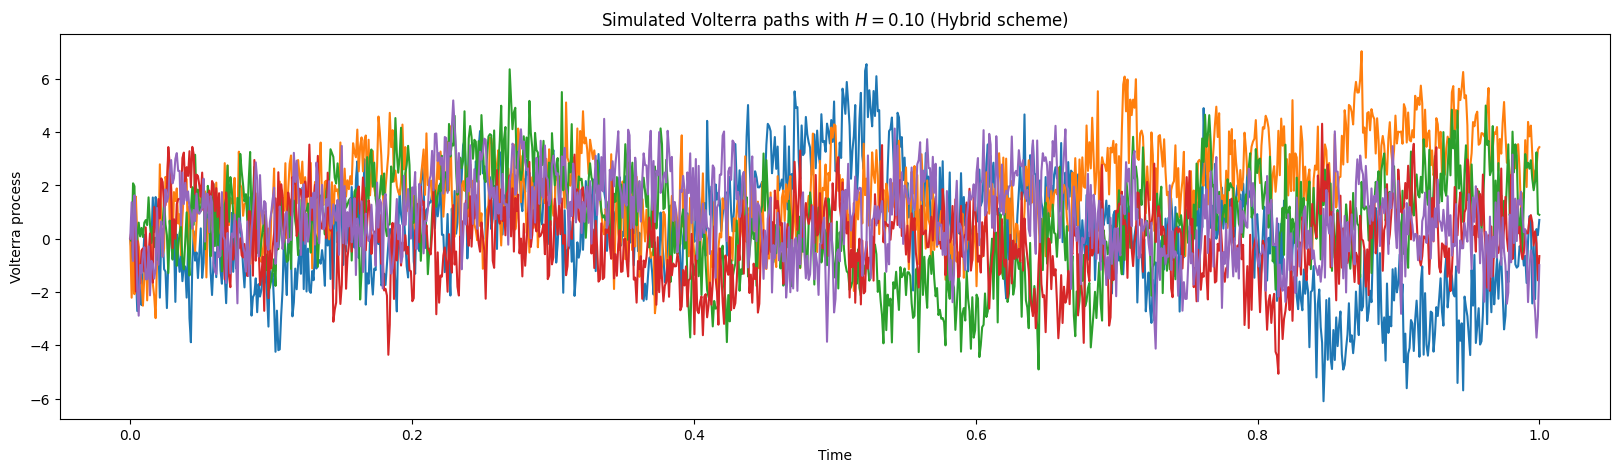

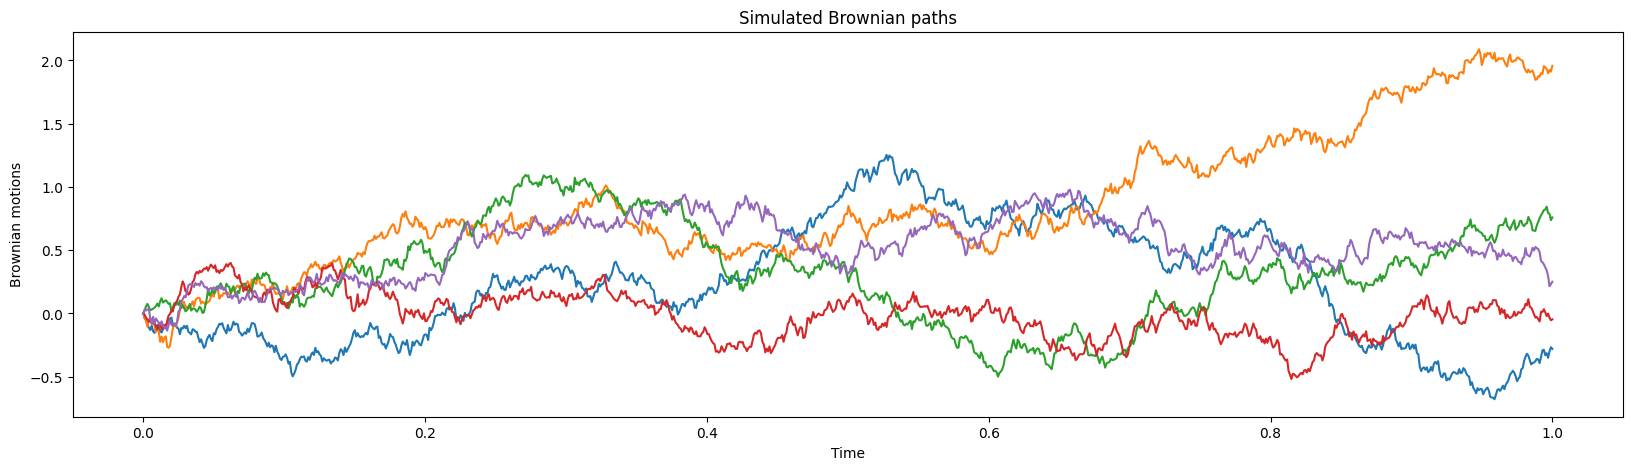

In [7]:
fBmpath, Bmpath = hybrid_scheme(grid_points, M, T, H, kappa)
times = np.linspace(0,T,grid_points)

plt.figure(figsize=(20, 5))
for i in range(M):
    plt.plot(times,fBmpath[i,:]) 
    
plt.xlabel('Time')
plt.ylabel('Volterra process')
plt.title('Simulated Volterra paths with $H=%1.2f$ (Hybrid scheme)'%H)
plt.show()


plt.figure(figsize=(20, 5))
for i in range(M):
    plt.plot(times,Bmpath[i,:]) 
    
    
plt.xlabel('Time')
plt.ylabel('Brownian motions')
plt.title('Simulated Brownian paths')
plt.show()

## Stock price dynamics under rBergomi

The rough Bergomi model reads

\begin{equation}
\begin{cases} 
S_t & = \displaystyle S_0 \exp\left\lbrace-\frac{1}{2}\int_0^t v_u du + \int_o^t\sqrt{v_u}dW_u\right\rbrace,\\
\displaystyle v_t & = \displaystyle \xi_0(t)\mathcal{E}\left(2\nu C_{H}V_t\right)
 = \xi_0(t)\exp\left\{2\nu C_{H}V_t - 2\nu^2 C_{H}^2[V_t]\right\},\\
\displaystyle V_t & = \displaystyle \int_{0}^t \frac{dZ_u}{(t-u)^{1/2-H}},\\
\displaystyle dW_t dZ_t & = \displaystyle \rho dt.
\end{cases}
\end{equation}
with $S_0, \nu,\xi_0>0$, and where $(V_t)_{t\geq 0}$ is the Gaussian Volterra process introduced previously.

Using the hybrid scheme above for $V$, we can write
$$
V\left(\frac{1}{n}\right)=\int_{0}^{1/n}\frac{dZ_u}{(1/n-u)^{1/2-H}}\approx \left(\frac{1}{n}\right)^{1/2-H} \left(Z_{1/n}-Z_{0}\right),
$$
using the forward Euler discretisation. This coincides with the Hybrid scheme
$$
V\left(\frac{1}{n}\right)=\tilde{V}_n(1)=\int_{0}^{1/n}\frac{dZ_u}{(1/n-u)^{1/2-H}}.
$$
In general, for $i>\kappa$ we may use from the Hybrid Scheme
$$
W_{i-1}=\left(Z_{i/n}^{\mathbb{Q}}-Z_{(i-1)/n}\right),
$$
so that 
$$
\left(W_{i/n} - W_{(i-1)/n}\right)=\rho\left(Z_{i/n} - Z_{(i-1)/n}\right)+\sqrt{1-\rho^2}\left(Z_{i/n}^{\perp}-Z_{(i-1)/n}^{\perp}\right),
$$
where $Z^{\perp}$ is a BM independent of $Z$.
We note in passing that 
$$
\mathbb{E}[V_t W_t]=\rho \frac{t^{H+1/2}}{H+1/2}.
$$

In [ ]:
def rBergomi_hybrid(grid_points, M, T, H, kappa, S0, xi0, nu, rho):
    """
    grid_points: number of points in the simulation grid
    kappa: parameter (equal to 1 or 2)
    H: Hurst parameter
    M: number of paths to simulate
    T: time horizon
    xi0: initial forward variance curve
    nu: volatility model parameter
    rho:BM correlation parameter
    """
    
    grid = np.linspace(0,T,grid_points)
    alpha = H-0.5
    n = grid[1]
    #compute optimal b_k=(b^*_k)^(H-1/2) for k>kappa+1
    aux = grid_points-kappa-1
    k1 = np.arange(kappa)+1
    k2 = np.arange(aux)+kappa+1

    #create the correlated Gaussian processes
    VAR1 = (np.power(k1,2*H)-np.power(k1-1,2*H))*np.power(n,2*H)/(2.0*H)
    VAR2 = n
    COV = (np.power(k1,alpha+1)-np.power(k1-1,alpha+1))*np.power(n,alpha+1)/(alpha+1)
    #create mean vector
    mean = np.zeros(kappa+1)
    #create covariance matrix
    cov = np.diag(np.append(VAR1,VAR2)) 
    cov[0:kappa,kappa] = COV
    cov[kappa,0:kappa] = COV
    
    if kappa>1:
        COV1 = np.power(n,2.0*alpha+1)/(alpha+1)*special.hyp2f1(1,2.0*(alpha+1),alpha+2,-1.0)*np.power(2.0,alpha+1)
        cov[0,1] = COV1
        cov[1,0] = COV1
    
    #Create optimal b*_k
    b_k = np.power(n,alpha)*((np.power(k2,alpha+1)-np.power(k2-1,alpha+1))/(alpha+1))
    a_k = np.array([np.append(np.zeros(kappa),b_k)])
    
    #Create the correlated random samples carefully to be consistent with parallel computing
    size = (grid_points-1)*M
    local_state = np.random.RandomState(None)
    RAND = local_state.multivariate_normal(mean, cov, size)
    
    #print(RAND.nbytes)
    RAND1 = RAND[:,0:kappa]
    
    #Compute also the first kappa samples of  correlated BM W, which drives the stock price
    W = np.zeros([M,grid_points-1])
    rho_comp = np.power(1-np.power(rho,2),0.5)
    index = np.arange(M)*(grid_points-1)
    local_state = np.random.RandomState(None)
    for i in range(kappa):
        W[:,i] = rho*RAND[index+i,i]*np.power(VAR1[i]/n,-0.5) + rho_comp*np.power(n,0.5)*local_state.normal(loc=0., scale=1., size=M)
    
    #If kappa>1 modify compute X1 first
    if kappa>1:
        RAND1[1:size,1] = RAND1[0:size-1,1]
        RAND1[np.arange(M)*(grid_points-1),1] = 0
        RAND1 = np.sum(RAND1,axis=1)
        
    RAND1 = RAND1.reshape((M,grid_points-1))
    
    #Compute X2 using discrete convolution and  FFT
    RAND2 = RAND[:,kappa:kappa+1].reshape((M,grid_points-1))
    RAND = None
    u = signal.fftconvolve(a_k,RAND2[:,0:grid_points-1-kappa], mode='full') 
    
    #Also generate the correlated BM for the stock price
    local_state = np.random.RandomState(None)
    W[:,kappa:grid_points-1] = rho*RAND2[:,kappa:grid_points-1]+rho_comp*np.power(n,0.5)*local_state.normal(loc=0.0, scale=1.0, size=[M,grid_points-kappa-1])
    RAND2 = None
    
    #generate X(i/n)=X1(i/n)+X2(i/n)
    path = np.zeros([M,grid_points])
    
    path[:,1:grid_points] = u[:,0:grid_points-1]+RAND1
    u = None
    RAND1 = None
    C_H = np.power(2*H*special.gamma(3.0/2.0-H)/special.gamma(H+0.5)/special.gamma(2.0-2.0*H),0.5)

    volatility = np.power(xi0,0.5)*np.exp(path*C_H*nu-np.power(nu*C_H,2)*np.power(grid,2*H)/2/H)
    
    path = None
    
    #Once the volatility is simulated we can produce the stock dynamics using forward Euler method
    stock = S0 * np.ones([M,grid_points])
    
    for i in range(grid_points-1):
        stock[:,i+1] = stock[:,i]+stock[:,i]*volatility[:,i]*W[:,i]   
    W = None
    return (volatility,stock)

In [ ]:
H = 0.07
nbPaths = 2
grid_points = 2000
kappa = 2
T = 1.
S0 = 1.
xi0 = np.power(0.235,2)
nu = 0.8
rho = -0.5

(volatility,stock) = rBergomi_hybrid(grid_points, nbPaths, T, H, kappa, S0, xi0, nu, rho)

In [ ]:
times = np.linspace(0,T,grid_points)
plt.figure(figsize=(20, 5))
for i in range(nbPaths):
    plt.plot(times, volatility[i,:], linewidth=2)
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.title('Simulated paths of volatility (Hybrid Scheme)')
plt.show()

plt.figure(figsize=(20, 5))
for i in range(nbPaths):
    plt.plot(times, stock[i,:], linewidth=3)
plt.xlabel('Time')
plt.ylabel('Stock price')
plt.title('Simulated paths of stock price (Hybrid Scheme+Forward Euler)')
plt.show()

#### Numerical test for option pricing

In [ ]:
nbStrikes = 100
nbPaths = 10000
strikes = np.linspace(S0*np.exp(-0.4), S0*np.exp(0.4), nbStrikes)
Call_price = np.zeros(nbStrikes)
(volatility,stock) = rBergomi_hybrid(grid_points, nbPaths, T, H, kappa, S0, xi0, nu, rho)

for i  in range(nbStrikes):
    Call_price[i] = np.mean(np.maximum(stock[:,grid_points-1] - strikes[i],0))

In [ ]:
log_moneyness = np.log(strikes/S0)

plt.figure(figsize=(10, 5))
plt.plot(log_moneyness,Call_price) 
plt.xlabel('log-moneyness')
plt.ylabel('Call Option price')
plt.title('Call Option price rBergomi (Hybrid Scheme+Forward Euler)')
plt.show()